In [1]:
import xgboost
import lightgbm
import missingno
import sklearn

print(xgboost.__version__)
print(lightgbm.__version__)
print(missingno.__version__)
print(sklearn.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [2]:
!pip install xgboost

!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 47.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 43.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.8 MB/s eta 0:00:00


In [4]:
!pip install missingno

In [5]:

import xgboost

import lightgbm
import missingno
import sklearn

print(xgboost.__version__)
print(lightgbm.__version__)
print(missingno.__version__)
print(sklearn.__version__)


3.2.0
4.6.0
0.5.2
1.7.0


## 버전확인후 이제 데이터를 불러와서 나만의 데이터러닝머신을 만들어보자


In [14]:
import pandas as pd
import numpy as np
import os
from os.path import join

# 1. 데이터 경로 설정 (사진의 경로 기준)
data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')

train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv') 

# 2. 데이터 불러오기
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

# 3. 데이터 확인 
print("학습 데이터 크기:", train.shape)
print("테스트 데이터 크기:", test.shape)
display(train.head())

학습 데이터 크기: (15035, 21)
테스트 데이터 크기: (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


##전처리하기
>당장의 필요없는 데이터를 제거하고 나중에 훈련데이터로 쓰기위해 따로보관해두자!!


In [15]:
#y 변수에 옮겨두기

y = train['price']

# 정답을 미리 보고 공부하면 안 되니까 삭제
del train['price']

# sub_id에 따로 보관합니다.
train_id = train['id']
test_id = test['id']

del train['id']
del test['id']

print("전처리 후 학습 데이터 컬럼:", train.columns)
print("타겟 데이터(y) 크기:", y.shape)

전처리 후 학습 데이터 컬럼: Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')
타겟 데이터(y) 크기: (15035,)


In [31]:
if 'date' in train.columns:
    del train['date']

if 'date' in test.columns:
    del test['date']

## 타겟 데이터(y) 로그로 변환
기존에 노드10에서 공부했을때 집값 데이터가 비싼집은 별로없었고 평균가격대의집이
왼쪽으로 치우쳐있다는걸 나는 알기때문에 지금 데이터대로 학습시키면 오차범위가 커서 학습이
제대로 안될거같음.. 그래서 아까 후반부에 배운 데이터를 변환시켜줘서 최대한 평균값으로 학습을 시켜보자.

Text(0.5, 1.0, 'Original Price Distribution')

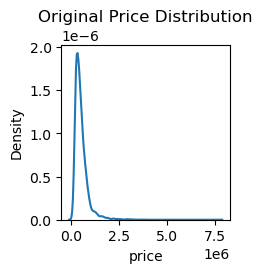

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 원래 가격 데이터의 분포 확인
plt.figure(figsize=(10, 5))
plt.subplot(2, 4, 2)
sns.kdeplot(y)
plt.title('Original Price Distribution')



In [17]:
# 2. 로그 변환 수행 (np.log1p 사용)
y = np.log1p(y)

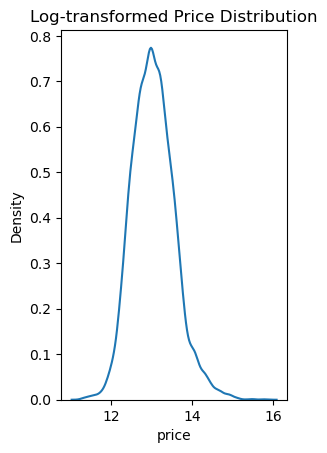

In [18]:
# 3. 변환 후 가격 데이터의 분포 확인
plt.subplot(1, 2, 2)
sns.kdeplot(y)
plt.title('Log-transformed Price Distribution')

plt.show()

왼쪽으로 치우쳤던게 정규분포 모양으로 잘 잡혔으 굿잡 乃

## 인공지능 일시키기
다듬은 데이터를 이제 인공지능한테 일시켜보자
노드에서 추천해준 lgm랑 xgb 그리고 시간이돼면 랜덤포레스트까지 조져..러닝 시켜봅시다

In [29]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. 공부용 데이터 시험용 데이터 8:2로 나누기 <<이건 국룰임..
X_train, X_test, y_train, y_test = train_test_split(train, y, test_size=0.2, random_state=42)

In [30]:
# 2. LightGBM 모델 만들기 (가장 기본적인 설정으로!) <<이것도 국룰임
model = LGBMRegressor(random_state=42)

In [32]:
# 3. 모델에게 공부 시키기

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("모델 학습 및 예측 완료!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2284
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 18
[LightGBM] [Info] Start training from score 13.047364
모델 학습 및 예측 완료!


In [37]:
real_y_pred = np.expm1(y_pred)
real_y_test = np.expm1(y_test)
rmse_val = np.sqrt(mean_squared_error(real_y_test, real_y_pred))

print(f"나의 첫 일꾼 RMSE 점수: {rmse_val:,.4f}")

나의 첫 일꾼 RMSE 점수: 121,528.0194


# XGB도 일시켜보자

In [40]:
from xgboost import XGBRegressor

# 1. 모델 만들기
xgb_model = XGBRegressor(random_state=42)

# 2. 공부시키기
xgb_model.fit(X_train, y_train)

# 3. 시험보기
xgb_y_pred = xgb_model.predict(X_test)

# 4. 점수 계산 (로그를 다시 숫자로 되돌려서!)
xgb_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(xgb_y_pred)))

print(f"XGBoost 모델의 RMSE 점수: {xgb_rmse:,.4f}")

XGBoost 모델의 RMSE 점수: 130,581.2421


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. 모델 만들기
gb_model = GradientBoostingRegressor(random_state=42)

# 2. 공부시키기
gb_model.fit(X_train, y_train)

# 3. 시험보기
gb_y_pred = gb_model.predict(X_test)

# 4. 점수 계산
gb_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(gb_y_pred)))

print(f"Gradient Boosting 모델의 RMSE 점수: {gb_rmse:,.4f}")

Gradient Boosting 모델의 RMSE 점수: 134,767.9352


In [42]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 만들기
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. 공부시키기
rf_model.fit(X_train, y_train)

# 3. 시험보기
rf_y_pred = rf_model.predict(X_test)

# 4. 점수 계산
rf_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(rf_y_pred)))

print(f"Random Forest 모델의 RMSE 점수: {rf_rmse:,.4f}")

Random Forest 모델의 RMSE 점수: 140,396.8884


### 하이퍼 파라미터 튜닝로 더 빡세게 일시키기
4가지 인공지능 시험치게했는데 저번 자전거대여에서 하드캐리한 랜덤포레스트가 꼴찌를...
처음 시험친 lgbm으로 더 빡세게 일시켜보겠습니다.
(군대나 ai 사회나 일잘하면 더 일만하는구나....)

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
param_grid = {
    'n_estimators': [50, 100],      # 나무 개수
    'max_depth': [1, 10, 20],       # 나무 깊이
    'learning_rate': [0.05, 0.1]    # 학습 속도 <<<기존 노드에서는 없었는데 ai친구가 추천해줬음 이래야 더일한다고..
}

In [53]:
lgbm = LGBMRegressor(random_state=42)#<<국룰 42입력

In [54]:
#2*2=4가지 를 5조각으로 조져보자
grid_model = GridSearchCV(lgbm, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=1, n_jobs=-1)##이것도 기존 노드에서는 5였는데 1로 바꾸면 cpu를 더빡세게 일시켜서 속도가 빨라짐..

In [55]:
grid_model.fit(train, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2282
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 18
[LightGBM] [Info] Start training from score 13.050187
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

,estimator,LGBMRegressor(random_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [1, 10, ...], 'n_estimators': [50, 100]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [56]:
print("최적의 파라미터:", grid_model.best_params_)
print("최고 점수(MSE):", grid_model.best_score_)

최적의 파라미터: {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 100}
최고 점수(MSE): -0.02777980162157647


####아직 로그변환을 안해서 잘모르겠지만 괜찬게 나온것 같다... 아마도?..

In [57]:
grid_model.cv_results_

{'mean_fit_time': array([0.12729516, 0.17826939, 0.36999621, 0.61816883, 0.33782735,
        0.69184804, 0.1246366 , 0.16847873, 0.31212349, 0.51913719,
        0.32772527, 0.5266592 ]),
 'std_fit_time': array([0.01446607, 0.01099033, 0.06529086, 0.07770309, 0.01049424,
        0.10761218, 0.0082988 , 0.00761605, 0.0072425 , 0.03055069,
        0.01883251, 0.02659348]),
 'mean_score_time': array([0.00951786, 0.01268163, 0.01943283, 0.04381461, 0.02137642,
        0.04144101, 0.01134524, 0.01194067, 0.02131925, 0.0380404 ,
        0.02183833, 0.04462867]),
 'std_score_time': array([0.00236663, 0.00098184, 0.0007932 , 0.01027302, 0.00285745,
        0.00114534, 0.00522841, 0.00042603, 0.00037222, 0.00055976,
        0.00101322, 0.00817664]),
 'param_learning_rate': masked_array(data=[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1,
                    0.1, 0.1],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, Fal

In [58]:
params = grid_model.cv_results_['params']
params
score = grid_model.cv_results_['mean_test_score']
score

array([-0.10455588, -0.07410433, -0.03742312, -0.02960452, -0.03740555,
       -0.0295038 , -0.07339447, -0.05502043, -0.02978527, -0.02778144,
       -0.02965024, -0.0277798 ])

In [59]:
results = pd.DataFrame(params)
results['score'] = score

results

,learning_rate,max_depth,n_estimators,score
0,0.05,1,50,-0.104556
1,0.05,1,100,-0.074104
2,0.05,10,50,-0.037423
3,0.05,10,100,-0.029605
4,0.05,20,50,-0.037406
5,0.05,20,100,-0.029504
6,0.10,1,50,-0.073394
7,0.10,1,100,-0.055020
8,0.10,10,50,-0.029785
9,0.10,10,100,-0.027781



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

노드에서 처럼 진행하다가 굳이 이것까지 전처리를 할필요가있을까....라는 의문이
그냥바로 rmse값을 찾아보자..

In [60]:
# 1. 그리드 탐색이 찾은 '최강노예 1호'
best_model = grid_model.best_estimator_

In [61]:
#노예 1호 입학시험치기
y_pred = best_model.predict(X_test)

In [62]:
# 3. 로그를 원래 집값으로 되돌리기 오차값이(mse)음수이며 보기 불편하니까
real_y_pred = np.expm1(y_pred)
real_y_test = np.expm1(y_test)

In [63]:
# 4. 진짜 RMSE 점수 계산
final_rmse = np.sqrt(mean_squared_error(real_y_test, real_y_pred))

print(f"노예1호 의 최종 RMSE 점수: {final_rmse:,.4f}")

노예1호 의 최종 RMSE 점수: 94,480.8691


########샤갈 저 됐어요 11만 밑으로 통과되었어요. 노예1호 입사 축하합니다.

In [64]:
SlaveNo1 = best_model.predict(test)

In [67]:
SlaveNo1 = np.expm1(SlaveNo1)

In [68]:
submission = pd.DataFrame(data={'id': test_id, 'price': SlaveNo1})

In [71]:
submission_csv_path = join(data_dir, 'submission_New_SlaveNo1.csv')
submission.to_csv(submission_csv_path, index=False)
print(f"제출 파일 {submission_csv_path}")

제출 파일 /home/jovyan/work/kaggle_kakr_housing/data/submission_New_SlaveNo1.csv


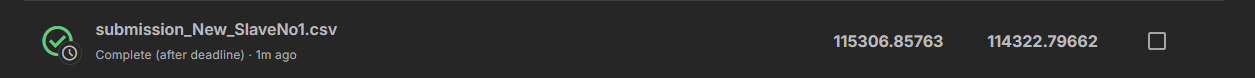

????? 쌰칼 왜 올리니까 점수가... ㅜㅜ

다시 하이퍼 단계부터 일시켜보자


In [72]:
param_grid = {
    'n_estimators': [1000, 2000],      #실행횟수도 확늘려보고
    'max_depth': [5, 10],              
    'learning_rate': [0.01, 0.05],     
    'num_leaves': [31, 63],            # LightGBM의 핵심 파라미터 추가
}

In [74]:
lgbm = LGBMRegressor(random_state=42)

In [75]:
grid_model = GridSearchCV(lgbm, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=1, n_jobs=-1)
grid_model.fit(train, y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2313
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 18
[LightGBM] [Info] Start training from score 13.052839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,estimator,LGBMRegressor(random_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05], 'max_depth': [5, 10], 'n_estimators': [1000, 2000], 'num_leaves': [31, 63]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


## ↑↑↑↑↑↑너무 길이서 닫아놨어요 결과값

In [76]:
best_model = grid_model.best_estimator_
y_pred = best_model.predict(X_test)
real_y_pred = np.expm1(y_pred)
real_y_test = np.expm1(y_test)
final_rmse = np.sqrt(mean_squared_error(real_y_test, real_y_pred))

print(f"노예2호 의 최종 RMSE 점수: {final_rmse:,.4f}")

노예2호 의 최종 RMSE 점수: 80,634.0620

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

이자식 더 일시키지 말라고 시위를하네...역시 현대판 노예는 인권이...

In [78]:
SlaveNo1 = best_model.predict(test)
SlaveNo1 = np.expm1(SlaveNo1)
submission = pd.DataFrame(data={'id': test_id, 'price': SlaveNo1})
submission_csv_path = join(data_dir, 'submission_New_SlaveNo2.csv')
submission.to_csv(submission_csv_path, index=False)
print(f"제출 파일 {submission_csv_path}")

제출 파일 /home/jovyan/work/kaggle_kakr_housing/data/submission_New_SlaveNo2.csv


In [79]:

prediction = best_model.predict(test)


prediction = np.expm1(prediction)


submission = pd.DataFrame(data={'id': test_id, 'price': prediction})


submission_csv_path = join(data_dir, 'submission_lgbm_final.csv')
submission.to_csv(submission_csv_path, index=False)

print(f"제출 파일 {submission_csv_path}")

제출 파일 /home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_final.csv


In [82]:
def save_submission(model, train, y, test, model_name, rmsle=None):
   
    model.fit(train, y)
    
   
    prediction = model.predict(test)
    
    #예측값을 다시 원래 가격으로 변환
    prediction = np.expm1(prediction)
    
    # 샘플 제출 파일을 불러와서 예측값을 덮어씌웁니다.
    data_dir = '/home/jovyan/work/kaggle_kakr_housing/data' # 사용자 환경에 맞춰 확인
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    
    
    file_name = '{}/submission_{}_{}.csv'.format(data_dir, model_name, rmsle if rmsle else 'final')
    submission.to_csv(file_name, index=False)
    
    print('{} saved!'.format(file_name))

# 2. 우리가 찾은 최적의 하이퍼 파라미터로 모델 설정
# 아까 GridSearchCV 결과: learning_rate=0.1, max_depth=20, n_estimators=100 
best_lgbm = LGBMRegressor(learning_rate=0.1, 
                          max_depth=20, 
                          n_estimators=100, 
                          num_leaves=63, # 아까 성능이 좋았던 값 추가
                          random_state=42)


save_submission(best_lgbm, train, y, test, 'lgbm', rmsle='slaveno1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 18
[LightGBM] [Info] Start training from score 13.048122
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_slaveno1.csv saved!


## ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ아무리해도 점수가더 오르는매직..
머리아파서 커피마시러 갔다왔는데 원두를 보고 블랜딩 해보자 생각이 팍 났음
앙상블 관현악단을 만들어보자,,,,,,,,

In [83]:
# 1. LightGBM 노예1호
model_lgbm = LGBMRegressor(n_estimators=1000, max_depth=7, random_state=42)
model_lgbm.fit(train, y)
pred_lgbm = np.expm1(model_lgbm.predict(test))

# 2. XGBoost 노예2호
model_xgb = XGBRegressor(n_estimators=1000, max_depth=7, random_state=42)
model_xgb.fit(train, y)
pred_xgb = np.expm1(model_xgb.predict(test))

# 3. 두 결과 섞기 (5:5 비율)
final_pred = (pred_lgbm * 0.5) + (pred_xgb * 0.5)

# 4. 저장
submission['price'] = final_pred
submission.to_csv('submission_ensemble.csv', index=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 18
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [86]:
lgbm_val_pred = np.expm1(model_lgbm.predict(X_test))
xgb_val_pred = np.expm1(model_xgb.predict(X_test))

# 5:5로 섞기
ensemble_val_pred = (lgbm_val_pred * 0.5) + (xgb_val_pred * 0.5)

# 실제 정답(y_test)과 비교해서 RMSE 계산
from sklearn.metrics import mean_squared_error
ensemble_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), ensemble_val_pred))

print(f"앙상블 모델의 검증 RMSE 점수: {ensemble_rmse:,.4f}")

앙상블 모델의 검증 RMSE 점수: 21,877.3903


In [87]:


model_name = 'avengersLave_lgbm_xgb'
save_path = f'./submission_{model_name}.csv'


submission.to_csv(save_path, index=False)

print(f"최종 제출 파일 {save_path}")

최종 제출 파일 ./submission_avengersLave_lgbm_xgb.csv


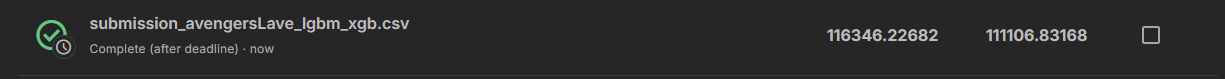
##ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 아니무슨 5배차이 역사의 길이남을 과적합 입니다..

이건 그동안 이 노트북에 쓸대없는 실험이 가득해서 오류가 걸린거라 생각한다.
새로운 노트파일을 열어서 스피드하게 노예어벤져스 앙상블을 돌려봐서 안되면 포기하겠습니다 퍼실님...